# Train vs Test 分布比較 & 欠損値テーブル

学習データ (`train.csv`) とテストデータ (`test.csv`) の分布を比較し、データドリフトや欠損パターンの違いを可視化する。

In [1]:
"""Cell 0: Setup & Imports"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# プロジェクトルートをパスに追加
project_root = Path.cwd().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data import load_train, load_test
from src.config import TARGET_COL, ID_COL

# 色の統一
C_TRAIN = "#4C72B0"
C_TEST = "#DD8452"
LABELS = {"train": "Train", "test": "Test"}

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 1. データ読み込み & 基本情報

In [2]:
train = load_train()
test = load_test()

# 分析対象カラム（ID・目的変数を除く）
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET_COL]]
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["pclass", "sex", "embarked"]

print(f"Train shape: {train.shape}")
print(f"Test  shape: {test.shape}")
print(f"\nFeature columns: {feature_cols}")
print(f"Numeric : {num_cols}")
print(f"Category: {cat_cols}")

Train shape: (445, 9)
Test  shape: (446, 8)

Feature columns: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Numeric : ['age', 'fare', 'sibsp', 'parch']
Category: ['pclass', 'sex', 'embarked']


## 2. 欠損値比較テーブル

In [3]:
# 欠損値テーブルの作成
def missing_table(df_train, df_test, cols):
    records = []
    for c in cols:
        tr_n = df_train[c].isna().sum()
        tr_pct = tr_n / len(df_train) * 100
        te_n = df_test[c].isna().sum()
        te_pct = te_n / len(df_test) * 100
        records.append({
            "column": c,
            "train_missing": tr_n,
            "train_pct": tr_pct,
            "test_missing": te_n,
            "test_pct": te_pct,
            "delta_pct": te_pct - tr_pct,
        })
    return pd.DataFrame(records).sort_values("train_pct", ascending=False).reset_index(drop=True)

miss_df = missing_table(train, test, feature_cols)

# Styler: >10% をハイライト
def highlight_high_missing(val):
    return "background-color: #FFCCCC" if val > 10 else ""

miss_df.style.map(
    highlight_high_missing, subset=["train_pct", "test_pct"]
).format({
    "train_pct": "{:.1f}%",
    "test_pct": "{:.1f}%",
    "delta_pct": "{:+.1f}pp",
})

,column,train_missing,train_pct,test_missing,test_pct,delta_pct
0,age,85,19.1%,92,20.6%,+1.5pp
1,embarked,2,0.4%,0,0.0%,-0.4pp
2,pclass,0,0.0%,0,0.0%,+0.0pp
3,sex,0,0.0%,0,0.0%,+0.0pp
4,sibsp,0,0.0%,0,0.0%,+0.0pp
5,parch,0,0.0%,0,0.0%,+0.0pp
6,fare,0,0.0%,0,0.0%,+0.0pp


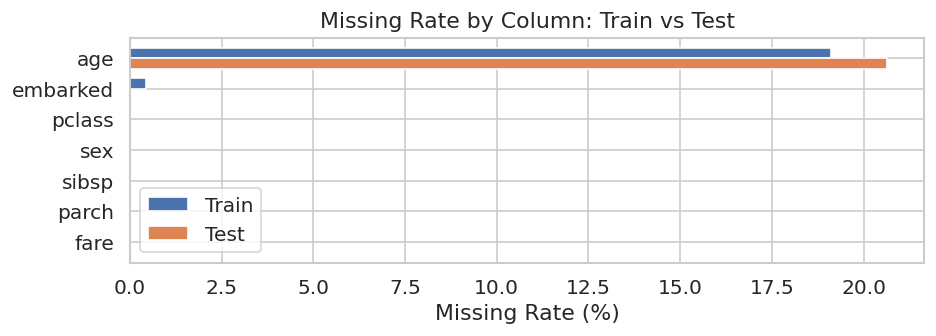

In [4]:
# 欠損率の横棒グラフ
fig, ax = plt.subplots(figsize=(8, 3))
y_pos = np.arange(len(miss_df))
bar_h = 0.35

ax.barh(y_pos - bar_h / 2, miss_df["train_pct"], bar_h, label="Train", color=C_TRAIN)
ax.barh(y_pos + bar_h / 2, miss_df["test_pct"], bar_h, label="Test", color=C_TEST)
ax.set_yticks(y_pos)
ax.set_yticklabels(miss_df["column"])
ax.set_xlabel("Missing Rate (%)")
ax.set_title("Missing Rate by Column: Train vs Test")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. 基本統計量の比較テーブル

In [5]:
# 数値カラムの基本統計量比較
stat_funcs = {
    "mean": "mean",
    "std": "std",
    "median": "median",
    "min": "min",
    "max": "max",
}

rows = []
for col in num_cols:
    for stat_name, method in stat_funcs.items():
        tr_val = getattr(train[col].dropna(), method)()
        te_val = getattr(test[col].dropna(), method)()
        rows.append({
            "column": col,
            "stat": stat_name,
            "train": tr_val,
            "test": te_val,
            "diff": te_val - tr_val,
        })

stats_df = pd.DataFrame(rows).pivot_table(
    index="column", columns="stat", values=["train", "test", "diff"]
)
# カラム順を整理
stats_df = stats_df.reindex(columns=pd.MultiIndex.from_product(
    [["train", "test", "diff"], ["mean", "std", "median", "min", "max"]]
))
stats_df.style.format("{:.2f}")

## 4. 数値特徴量の分布比較（KDE + ヒストグラム）

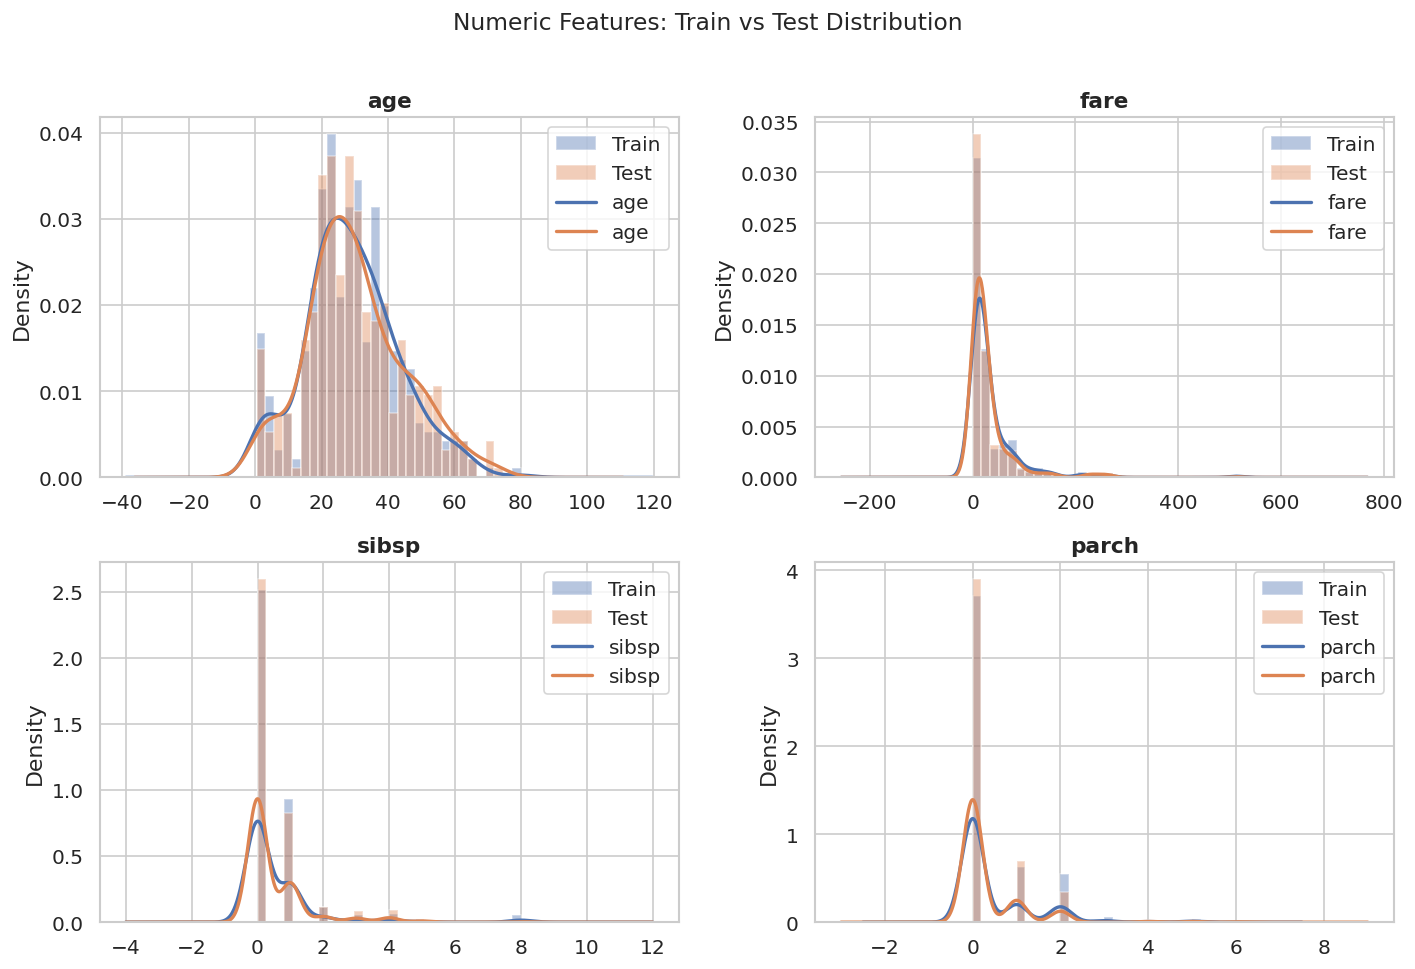

In [6]:
# 数値特徴量: KDE + ヒストグラム 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), num_cols):
    # 共通 bin 範囲
    combined = pd.concat([train[col].dropna(), test[col].dropna()])
    bins = np.linspace(combined.min(), combined.max(), 31)

    ax.hist(train[col].dropna(), bins=bins, density=True, alpha=0.4,
            color=C_TRAIN, label="Train", edgecolor="white")
    ax.hist(test[col].dropna(), bins=bins, density=True, alpha=0.4,
            color=C_TEST, label="Test", edgecolor="white")

    # KDE（データ数が十分な場合のみ）
    if train[col].dropna().nunique() > 5:
        train[col].dropna().plot.kde(ax=ax, color=C_TRAIN, lw=2)
        test[col].dropna().plot.kde(ax=ax, color=C_TEST, lw=2)

    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.legend()

plt.suptitle("Numeric Features: Train vs Test Distribution", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

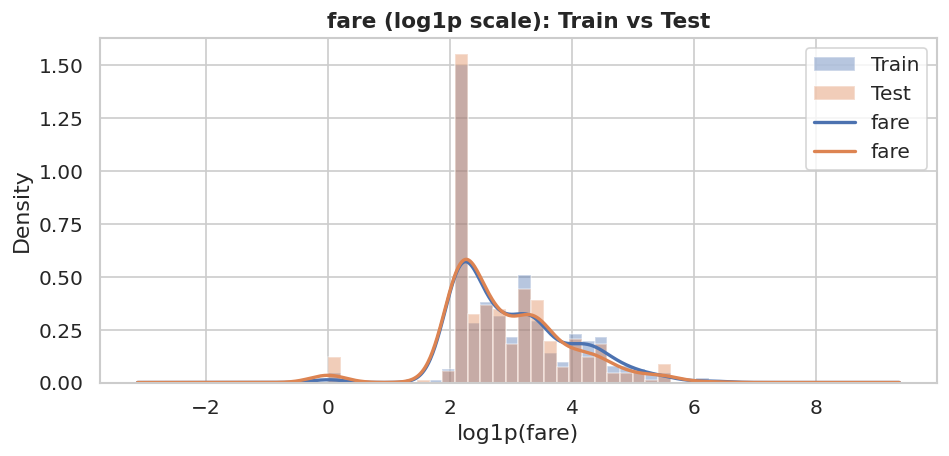

In [7]:
# fare の log1p スケール分布（ロングテール対策）
fig, ax = plt.subplots(figsize=(8, 4))

tr_fare_log = np.log1p(train["fare"].dropna())
te_fare_log = np.log1p(test["fare"].dropna())
combined_log = np.concatenate([tr_fare_log, te_fare_log])
bins = np.linspace(combined_log.min(), combined_log.max(), 31)

ax.hist(tr_fare_log, bins=bins, density=True, alpha=0.4,
        color=C_TRAIN, label="Train", edgecolor="white")
ax.hist(te_fare_log, bins=bins, density=True, alpha=0.4,
        color=C_TEST, label="Test", edgecolor="white")
tr_fare_log.plot.kde(ax=ax, color=C_TRAIN, lw=2)
te_fare_log.plot.kde(ax=ax, color=C_TEST, lw=2)

ax.set_title("fare (log1p scale): Train vs Test", fontsize=13, fontweight="bold")
ax.set_xlabel("log1p(fare)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. カテゴリ特徴量の分布比較

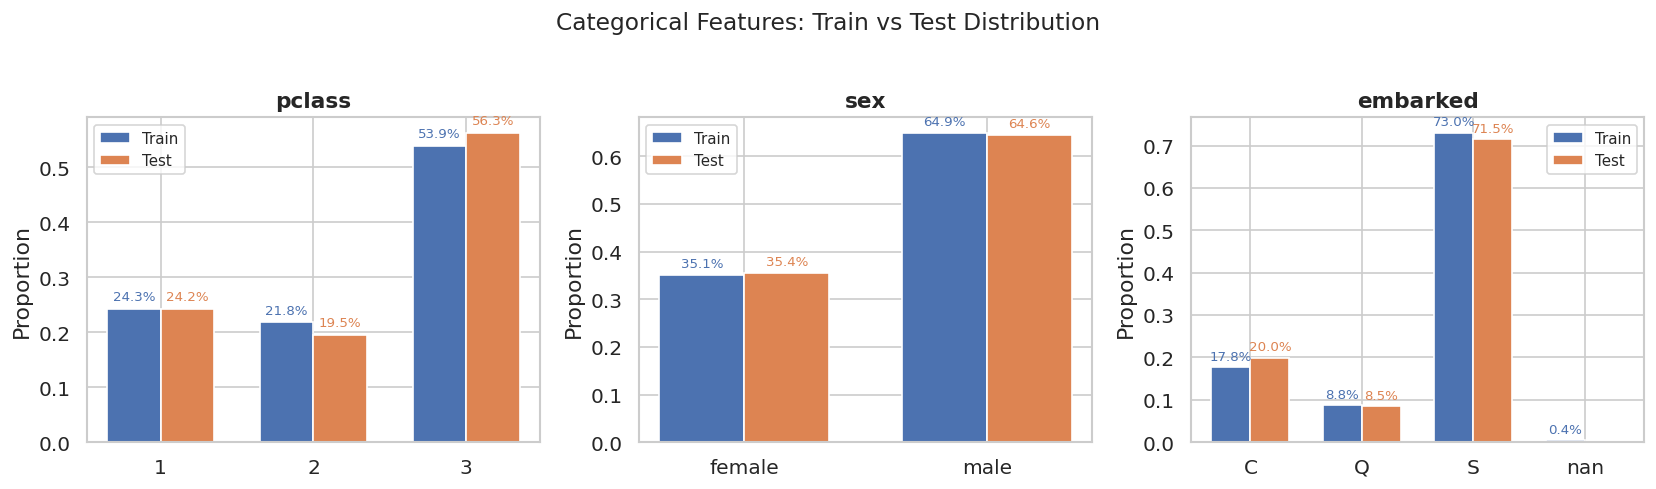

In [8]:
# カテゴリ特徴量: 正規化バーチャート 1x3
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, cat_cols):
    # 正規化カウント
    tr_counts = train[col].value_counts(normalize=True, dropna=False).sort_index()
    te_counts = test[col].value_counts(normalize=True, dropna=False).sort_index()

    # 全カテゴリを揃える
    all_cats = sorted(set(tr_counts.index) | set(te_counts.index), key=str)
    tr_vals = [tr_counts.get(c, 0) for c in all_cats]
    te_vals = [te_counts.get(c, 0) for c in all_cats]

    x = np.arange(len(all_cats))
    w = 0.35
    bars_tr = ax.bar(x - w / 2, tr_vals, w, label="Train", color=C_TRAIN)
    bars_te = ax.bar(x + w / 2, te_vals, w, label="Test", color=C_TEST)

    # アノテーション
    for bar in bars_tr:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.1%}", ha="center", va="bottom", fontsize=8, color=C_TRAIN)
    for bar in bars_te:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.1%}", ha="center", va="bottom", fontsize=8, color=C_TEST)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in all_cats])
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_ylabel("Proportion")
    ax.legend(fontsize=9)

plt.suptitle("Categorical Features: Train vs Test Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. 統計的検定によるドリフト定量化

- **数値特徴量**: KS検定（p値）+ Wasserstein距離
- **カテゴリ特徴量**: カイ二乗検定（p値）+ Cramér's V

In [9]:
# --- 数値特徴量のドリフト検定 ---
num_drift_rows = []
for col in num_cols:
    tr = train[col].dropna().values
    te = test[col].dropna().values

    # KS検定
    ks_stat, ks_p = stats.ks_2samp(tr, te)
    # Wasserstein距離
    w_dist = stats.wasserstein_distance(tr, te)

    num_drift_rows.append({
        "column": col,
        "type": "numeric",
        "test": "KS",
        "statistic": ks_stat,
        "p_value": ks_p,
        "wasserstein": w_dist,
    })

num_drift_df = pd.DataFrame(num_drift_rows)

# --- カテゴリ特徴量のドリフト検定 ---
cat_drift_rows = []
for col in cat_cols:
    # 欠損を文字列に変換して統一
    tr_vals = train[col].fillna("_MISSING_")
    te_vals = test[col].fillna("_MISSING_")

    all_cats = sorted(set(tr_vals) | set(te_vals), key=str)
    tr_counts = tr_vals.value_counts()
    te_counts = te_vals.value_counts()
    observed = np.array([[tr_counts.get(c, 0) for c in all_cats],
                         [te_counts.get(c, 0) for c in all_cats]])

    # カイ二乗検定
    chi2, chi2_p, dof, _ = stats.chi2_contingency(observed)
    # Cramér's V
    n = observed.sum()
    k = min(observed.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0.0

    cat_drift_rows.append({
        "column": col,
        "type": "categorical",
        "test": "Chi2",
        "statistic": chi2,
        "p_value": chi2_p,
        "cramers_v": cramers_v,
    })

cat_drift_df = pd.DataFrame(cat_drift_rows)

print("=== Numeric Features: KS Test & Wasserstein Distance ===")
display(num_drift_df.style.format({
    "statistic": "{:.4f}",
    "p_value": "{:.4f}",
    "wasserstein": "{:.4f}",
}))

print("\n=== Categorical Features: Chi-Square Test & Cramér's V ===")
display(cat_drift_df.style.format({
    "statistic": "{:.4f}",
    "p_value": "{:.4f}",
    "cramers_v": "{:.4f}",
}))

=== Numeric Features: KS Test & Wasserstein Distance ===


,column,type,test,statistic,p_value,wasserstein
0,age,numeric,KS,0.0477,0.7846,1.0638
1,fare,numeric,KS,0.0520,0.5621,3.8681
2,sibsp,numeric,KS,0.0209,0.9999,0.0814
3,parch,numeric,KS,0.0519,0.5648,0.1041



=== Categorical Features: Chi-Square Test & Cramér's V ===


,column,type,test,statistic,p_value,cramers_v
0,pclass,categorical,Chi2,0.7888,0.6741,0.0298
1,sex,categorical,Chi2,0.0021,0.9638,0.0015
2,embarked,categorical,Chi2,2.6630,0.4466,0.0547


## 7. Drift Summary & Takeaways

In [10]:
# 全特徴量のドリフト指標をまとめたランキングテーブル
summary_rows = []

for _, row in num_drift_df.iterrows():
    summary_rows.append({
        "column": row["column"],
        "type": "numeric",
        "test_method": "KS test",
        "statistic": row["statistic"],
        "p_value": row["p_value"],
        "effect_size": row["wasserstein"],
        "effect_metric": "Wasserstein",
        "drift_flag": "⚠️" if row["p_value"] < 0.05 else "✅",
    })

for _, row in cat_drift_df.iterrows():
    summary_rows.append({
        "column": row["column"],
        "type": "categorical",
        "test_method": "Chi-square",
        "statistic": row["statistic"],
        "p_value": row["p_value"],
        "effect_size": row["cramers_v"],
        "effect_metric": "Cramér's V",
        "drift_flag": "⚠️" if row["p_value"] < 0.05 else "✅",
    })

summary_df = pd.DataFrame(summary_rows).sort_values("p_value").reset_index(drop=True)

summary_df.style.format({
    "statistic": "{:.4f}",
    "p_value": "{:.4f}",
    "effect_size": "{:.4f}",
}).set_caption("Drift Summary: All Features (sorted by p-value)")

,column,type,test_method,statistic,p_value,effect_size,effect_metric,drift_flag
0,embarked,categorical,Chi-square,2.6630,0.4466,0.0547,Cramér's V,✅
1,fare,numeric,KS test,0.0520,0.5621,3.8681,Wasserstein,✅
2,parch,numeric,KS test,0.0519,0.5648,0.1041,Wasserstein,✅
3,pclass,categorical,Chi-square,0.7888,0.6741,0.0298,Cramér's V,✅
4,age,numeric,KS test,0.0477,0.7846,1.0638,Wasserstein,✅
5,sex,categorical,Chi-square,0.0021,0.9638,0.0015,Cramér's V,✅
6,sibsp,numeric,KS test,0.0209,0.9999,0.0814,Wasserstein,✅


### Takeaways / モデリングへの示唆

- **ドリフトが有意な特徴量** (`p < 0.05`): train と test で分布が統計的に異なる。これらの特徴量に強く依存するモデルは汎化性能に注意が必要。
- **Wasserstein距離・Cramér's V が大きい特徴量**: 分布の「ズレ幅」が大きいことを示す。特徴量エンジニアリング時にロバストな変換（ビニング、log変換等）を検討する。
- **欠損率の差 (delta)**: train と test で欠損パターンが異なる場合、欠損自体が情報を持つ可能性がある。欠損フラグの追加や、欠損補完手法の選択に影響する。
- **全体的に大きなドリフトが見られない場合**: train/test は同一母集団からのランダム分割と推定でき、CV スコアの信頼性が高い。